# 1 导入数据

In [1]:
# Install required packages (only run once if not already installed)
install.packages("haven")
install.packages("dplyr")
install.packages("skimr")

# Load the packages
library(haven)
library(dplyr)
library(skimr)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:

# 设置文件路径
file_path <- "/kaggle/input/ageiat-02-24/Age IAT.public.2002-2024.sav"
# 读取 SPSS 数据
data <- read_sav(file_path)



In [3]:
# 筛选所需变量
selected_vars <- c("session_id",
                   "age","birthyear", "year",
                   "sex", "birthsex", "genderIdentity_0002","transIdentity",
                   "att_5","att_7",
                   "D_biep.Young_Good_all","PCT_error_3467","pct_400",
                   "N_ERROR_3","N_ERROR_4","N_ERROR_6","N_ERROR_7",
                   "N_3","N_4","N_6","N_7",
                   "edu", "edu_9", "edu_13", "edu_14",
                   "major","occupation","occuselfdetail","occuself",
                   "ethnic","raceomb","raceomb_002","raceombmulti",
                   "country","countrycit","countrycit_num","countrycit003_num")

# 创建新的数据框，只保留需要的变量
data <- data %>% select(all_of(selected_vars))

# 2 处理年龄

In [4]:
#处理年龄
table(data$age,useNA="ifany")
table(data$birthyear,useNA="ifany")
table(data$year,useNA="ifany")


     -2       0       2       3       5       6       7       8       9      10 
      1    1223       3       4       1       1     392     300     367     597 
     11      12      13      14      15      16      17      18      19      20 
   1072    2873    7013   13400   23043   45864   72899   90061   82985   83181 
     21      22      23      24      25      26      27      28      29      30 
  77287   53796   38662   32190   29161   24303   22515   20404   18133   17983 
     31      32      33      34      35      36      37      38      39      40 
  15032   14623   13196   12287   13088   10897   10515    9942    9347   10403 
     41      42      43      44      45      46      47      48      49      50 
   8545    9301    8494    8140    8880    7959    7963    7677    7586    8718 
     51      52      53      54      55      56      57      58      59      60 
   6900    7054    6528    6198    6273    5295    4951    4372    3774    3749 
     61      62      63    


      1       2       3       4       5       6       7       8       9      10 
      2       2       1       5       8      13      32      86     117     309 
     11      12      13      14      15      16      17      18      19      20 
    481     532     494     487     671     519     416     382     315     304 
     21      22      23      24      25      26      27      28      29      30 
    298     274     287     243     236     210     199     173     180     185 
     31      32      33      34      35      36      37      38      39      40 
    173     164     180     167     152     149     132     129     128     125 
     41      42      43      44      45      46      47      48      49      50 
    117     136     104      97     102     104      97     104     103     110 
     51      52      53      54      55      56      57      58      59      60 
     88      74      91      82      63      76      56      42      31      27 
     61      62      63    


  2002   2003   2004   2005   2006   2007   2008   2009   2010   2011   2012 
     1  64161  85630 286549 116065 105050  94652 120593 105412 114216 133908 
  2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023 
119579 121977 209530 235792 239054 255648 301859 411330 452527 388151 342201 
  2024   <NA> 
296020      2 

In [5]:
# 处理 age：保留 [15, 89]，否则设为 NA
data$age <- ifelse(data$age >= 15 & data$age <= 89, data$age, NA)
table(data$age, useNA = "ifany")

# 处理 birthyear：保留 [1901, 2024]
data$birthyear <- ifelse(data$birthyear >= 1901 & data$birthyear <= 2024, data$birthyear, NA)
table(data$birthyear, useNA = "ifany")

# 处理 year：保留 [2002, 2024]
data$year <- ifelse(data$year >= 2002 & data$year <= 2024, data$year, NA)
table(data$year, useNA = "ifany")


     15      16      17      18      19      20      21      22      23      24 
  23043   45864   72899   90061   82985   83181   77287   53796   38662   32190 
     25      26      27      28      29      30      31      32      33      34 
  29161   24303   22515   20404   18133   17983   15032   14623   13196   12287 
     35      36      37      38      39      40      41      42      43      44 
  13088   10897   10515    9942    9347   10403    8545    9301    8494    8140 
     45      46      47      48      49      50      51      52      53      54 
   8880    7959    7963    7677    7586    8718    6900    7054    6528    6198 
     55      56      57      58      59      60      61      62      63      64 
   6273    5295    4951    4372    3774    3749    2996    2742    2210    1795 
     65      66      67      68      69      70      71      72      73      74 
   1687    1152    1075     896     654     650     482     425     362     303 
     75      76      77    


   1910    1911    1912    1913    1914    1915    1916    1917    1918    1919 
   2361     218     138     126     150     136     173     179     148     143 
   1920    1921    1922    1923    1924    1925    1926    1927    1928    1929 
    172     122     123     117      97      84      68      70      78      79 
   1930    1931    1932    1933    1934    1935    1936    1937    1938    1939 
     96      89      57      90     124     118     154     196     199     270 
   1940    1941    1942    1943    1944    1945    1946    1947    1948    1949 
    354     397     524     623     717     796    1103    1370    1537    1727 
   1950    1951    1952    1953    1954    1955    1956    1957    1958    1959 
   2225    2630    3172    3759    4519    5169    6359    7298    8233    9317 
   1960    1961    1962    1963    1964    1965    1966    1967    1968    1969 
  10614   11248   11973   13100   13747   14043   14356   14947   16048   17287 
   1970    1971    1972    


  2002   2003   2004   2005   2006   2007   2008   2009   2010   2011   2012 
     1  64161  85630 286549 116065 105050  94652 120593 105412 114216 133908 
  2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023 
119579 121977 209530 235792 239054 255648 301859 411330 452527 388151 342201 
  2024   <NA> 
296020      2 

In [6]:
# 保留 age、birthyear、year 中至多只有 1 个 NA 的行
data <- data[ rowSums(is.na(data[, c("age", "birthyear", "year")])) < 2, ]

In [7]:
# 步骤 1：创建新变量
data$Age <- data$age
data$Period <- data$year
data$Cohort <- data$birthyear

# 步骤 2：填补缺失值（通过代数关系）
# 注意：必须逐个判断另外两个是否非缺失
data$Age <- ifelse(is.na(data$Age) & !is.na(data$Period) & !is.na(data$Cohort),
                   data$Period - data$Cohort,
                   data$Age)

data$Period <- ifelse(is.na(data$Period) & !is.na(data$Cohort) & !is.na(data$Age),
                      data$Cohort + data$Age,
                      data$Period)

data$Cohort <- ifelse(is.na(data$Cohort) & !is.na(data$Period) & !is.na(data$Age),
                      data$Period - data$Age,
                      data$Cohort)




In [8]:
# 步骤 3：检查是否满足数学一致性（非缺失情况下）
check_relation <- with(data, 
                       !is.na(Age) & !is.na(Period) & !is.na(Cohort) & 
                       (Age != Period - Cohort))

# 输出不一致的行数（有错误的行）
sum(check_relation)  # 行数
which(check_relation)  # 哪些行出现问题（可选）

[1] 0

integer(0)

In [9]:
table(data$Age,useNA="ifany")
table(data$Period,useNA="ifany")
table(data$Cohort,useNA="ifany")


     0      1      2      3      4      5      6      7      8      9     10 
   334    412    499    466    421    316    264    232    249    292    396 
    11     12     13     14     15     16     17     18     19     20     21 
   869   2786   6184  13922  48728  88909 143093 229373 258743 243913 226058 
    22     23     24     25     26     27     28     29     30     31     32 
184796 137023 108772  89145  75513  68950  62765  57377  54821  50151  47737 
    33     34     35     36     37     38     39     40     41     42     43 
 44786  42245  41548  38255  36971  35474  34053  34766  31828  32148  30198 
    44     45     46     47     48     49     50     51     52     53     54 
 28967  29230  27634  27097  26295  25957  26835  24627  24191  23082  21877 
    55     56     57     58     59     60     61     62     63     64     65 
 21058  19333  18562  16888  15693  14932  13047  11889   9994   8712   7401 
    66     67     68     69     70     71     72     73     74 


  2002   2003   2004   2005   2006   2007   2008   2009   2010   2011   2012 
     1  31106  42775 127570  61344  61635  57930  72394  65429  71367  85236 
  2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023 
 76115  73827 114107 133140 157781 173450 204578 275402 304971 325156 307032 
  2024 
267372 


  1910   1911   1912   1913   1914   1915   1916   1917   1918   1919   1920 
  2361    218    138    126    150    139    175    180    156    151    190 
  1921   1922   1923   1924   1925   1926   1927   1928   1929   1930   1931 
   145    151    155    136    141    135    128    188    186    263    274 
  1932   1933   1934   1935   1936   1937   1938   1939   1940   1941   1942 
   262    307    406    452    524    628    740    866   1097   1334   1608 
  1943   1944   1945   1946   1947   1948   1949   1950   1951   1952   1953 
  2144   2416   2563   3193   4328   4657   5062   6049   6786   7775   8967 
  1954   1955   1956   1957   1958   1959   1960   1961   1962   1963   1964 
 10039  11087  12614  13555  15184  16222  18153  18984  19786  21235  22006 
  1965   1966   1967   1968   1969   1970   1971   1972   1973   1974   1975 
 22604  22997  23634  25115  26818  29626  29481  28540  28737  30322  31798 
  1976   1977   1978   1979   1980   1981   1982   1983   1984 

In [10]:
nrow(data)

[1] 3089718

In [11]:
data$Age <- ifelse(data$Age >= 15 & data$Age <= 89, data$Age, NA)
data <- data[!is.na(data$Age), ]


In [12]:
nrow(data)

[1] 3057049

# 3 处理性别

In [13]:
#处理性别
table(data$sex,useNA="ifany")
table(data$birthsex,useNA="ifany")
table(data$genderIdentity_0002,useNA="ifany")
table(data$transIdentity,useNA="ifany")


              .       F       f       m       n 
2048063    4212       1  672806  329896    2071 


      1       2    <NA> 
 466112 1004154 1586783 


      1       2       3       4    <NA> 
 113026  286288    5229     831 2651675 


      1       2       3    <NA> 
   3508  398655    3211 2651675 

In [14]:
data$sex_raw <- data$sex  # 保留原始值
# 确保 sex 是字符型（或转换成字符）
data$sex <- as.character(data$sex)

# 编码：1 = Female (F/f)，2 = Male (M/m/n)，其他 = NA
data$sex_clean <- ifelse(data$sex %in% c("F", "f"), 2,
                         ifelse(data$sex %in% c("m", "n"), 1, NA))



In [15]:
# 清理 genderIdentity_0002：只保留 1 和 2
data$genderIdentity_0002_clean <- ifelse(data$genderIdentity_0002 %in% c(1,2),
                                         data$genderIdentity_0002, NA)

# 构建统一的 Sex 变量
data$Sex <- with(data,
                 ifelse(year <= 2015, sex_clean,
                 ifelse(year <= 2022, birthsex,
                 genderIdentity_0002_clean)))
# 删除 genderIdentity_0002 == 3 or 4（仅在 2023–24 年有效）
data <- data[!(data$year >= 2023 & data$genderIdentity_0002 %in% c(3, 4)), ]

# 删除跨性别者（仅在 2023–24 年有效）
data <- data[!(data$year >= 2023 & data$transIdentity == 1), ]


In [16]:
table(data$Sex,useNA="ifany")
table(data$sex,useNA="ifany")
table(data$birthsex,useNA="ifany")
table(data$genderIdentity_0002,useNA="ifany")


      1       2    <NA> 
 875452 1884136  289608 


              .       f       F       m       n    <NA> 
1878307    4212  672806       1  329896    2071  161903 


      1       2    <NA> 
 453170  972124 1623902 


      1       2    <NA> 
 112040  285478 2651678 

In [17]:
nrow(data)

[1] 3049196

In [18]:
data <- data[!is.na(data$Sex), ]
nrow(data)

[1] 2759588

# 4 因变量——att

In [19]:
#att检查
table(data$att_5,useNA="ifany")
table(data$att_7,useNA="ifany")


      1       2       3       4       5    <NA> 
   1815   24455  109298   93341   12084 2518595 


      1       2       3       4       5       6       7    <NA> 
   7188   27830   80545  324434  177645  118209   33840 1989897 

In [20]:
data$att_5 <- ifelse(data$att_5 >= 1 & data$att_5 <= 5 , data$att_5,NA)
table(data$att_5,useNA="ifany")
data$att_7 <- ifelse(data$att_7 >= 1 & data$att_7 <= 7 , data$att_7,NA)
table(data$att_7,useNA="ifany")


      1       2       3       4       5    <NA> 
   1815   24455  109298   93341   12084 2518595 


      1       2       3       4       5       6       7    <NA> 
   7188   27830   80545  324434  177645  118209   33840 1989897 

In [21]:
# Step 1: 缩放 att_7 到 5 级
data$att_7_scaled <- 1 + (data$att_7 - 1) * (4 / 6)

# Step 2: 合并为统一变量（优先 att_5，如果是 NA 就用缩放后的 att_7）
data$Att <- ifelse(!is.na(data$att_5), data$att_5, data$att_7_scaled)

# Step 3: 检查
table(data$Att, useNA = "ifany") 
table(data$att_5,useNA="ifany")
table(data$att_7,useNA="ifany")



               1 1.66666666666667                2 2.33333333333333 
            9003            27830            24455            80545 
               3 3.66666666666667                4 4.33333333333333 
          433732           177645            93341           118209 
               5             <NA> 
           45924          1748904 


      1       2       3       4       5    <NA> 
   1815   24455  109298   93341   12084 2518595 


      1       2       3       4       5       6       7    <NA> 
   7188   27830   80545  324434  177645  118209   33840 1989897 

In [22]:
nrow(data)

[1] 2759588

# 4 因变量——iat

错误率标准：
#### 1.排除在所有试验中错误率超过30%的参与者:PCT_error_3467
#### 2.排除在任何单个区块中错误率超过40%的参与者:N_ERROR_3,N_ERROR_4,N_ERROR_6,N_ERROR_7
####  3.排除反应时间少于400毫秒的试验占比低于10%的参与者:pct_400

这些标准与之前使用IAT的研究一致（引用了Greenwald et al., 2003; Nosek et al., 2007; Westgate et al., 2015）
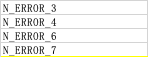
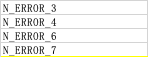
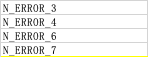
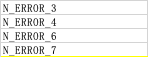

[1] 231047

Warning message in plot.window(xlim, ylim, "", ...):
“"useNA" is not a graphical parameter”


Warning message in title(main = main, sub = sub, xlab = xlab, ylab = ylab, ...):
“"useNA" is not a graphical parameter”


Warning message in axis(1, ...):
“"useNA" is not a graphical parameter”


Warning message in axis(2, at = yt, ...):
“"useNA" is not a graphical parameter”


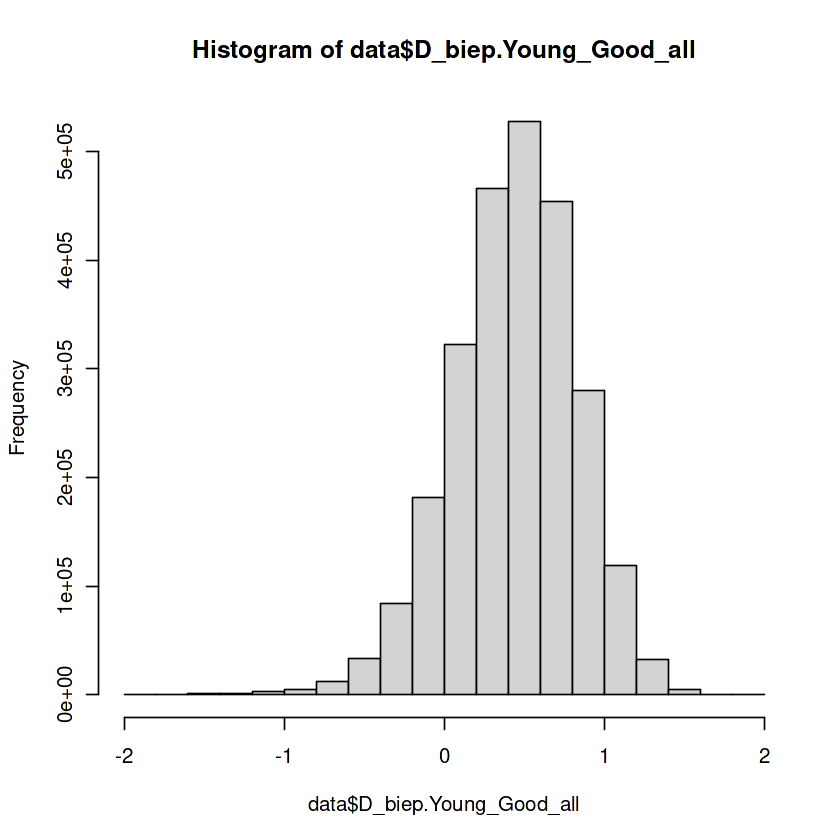

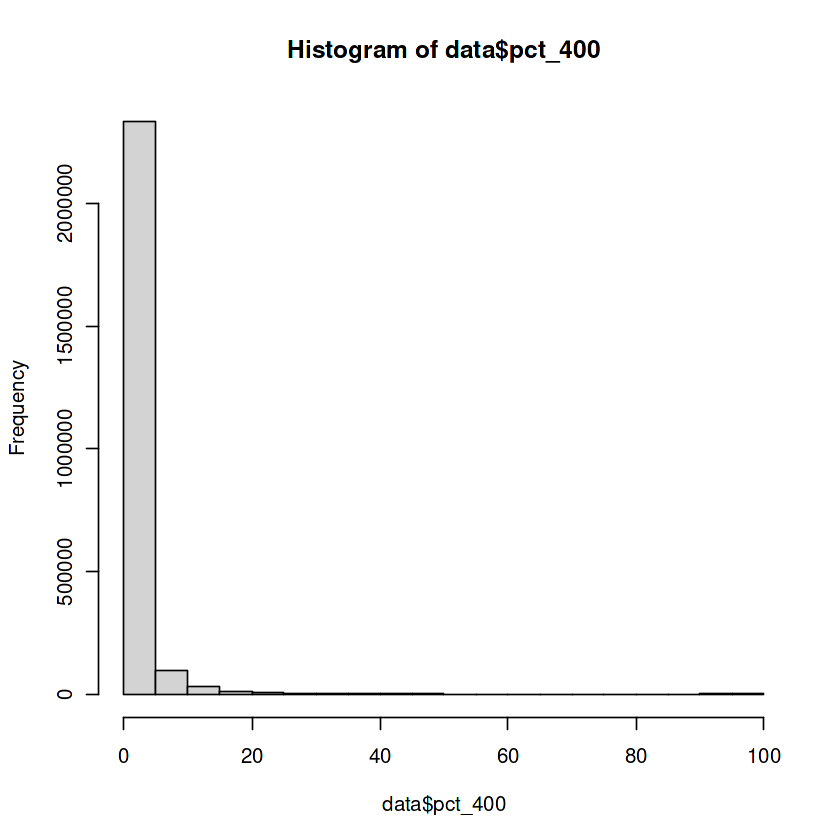

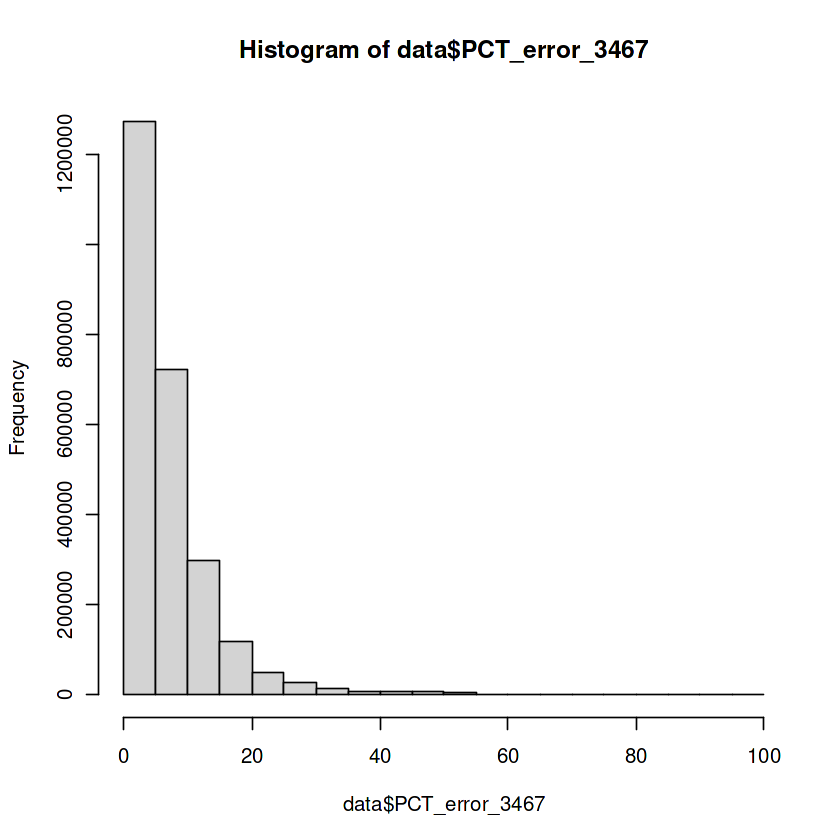

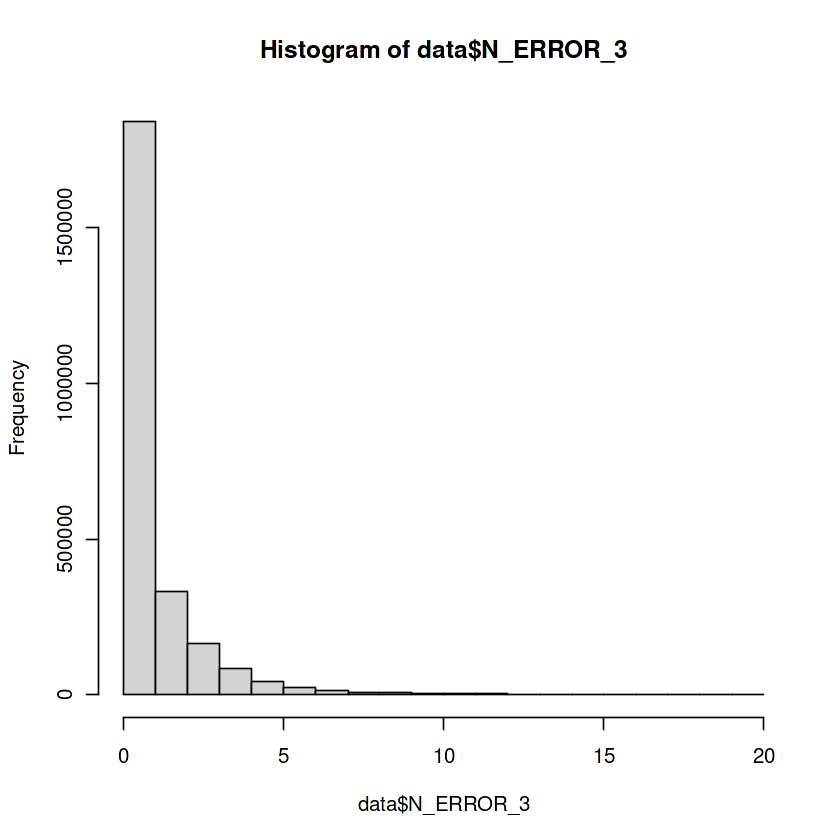

In [23]:
sum(is.na(data$D_biep.Young_Good_all))
hist(data$D_biep.Young_Good_all)
hist(data$pct_400,useNA="ifany")
hist(data$PCT_error_3467)
hist(data$N_ERROR_3)

In [24]:
# 创建一个函数来简化代码
check_filter <- function(data, condition_name) {
  cat(condition_name, ":", nrow(data), "\n")
  return(data)
}

cat("原始数据行数:", nrow(data), "\n")

data <- data %>%
  filter(!is.na(D_biep.Young_Good_all)) %>%
  check_filter("排除缺失D_biep.Young_Good_all后") %>%
  
  filter(PCT_error_3467 <= 30) %>%
  check_filter("排除总错误率>30%后") %>%
  
  filter(pct_400 <= 90)  %>% # 保留<400ms反应时间≤90%的参与者 
  check_filter("排除≥400ms反应时间<10%后") %>%
  
  filter(N_ERROR_3 / N_3 <= 0.4) %>%
  check_filter("排除区块3错误率>40%后") %>%
  
  filter(N_ERROR_4 / N_4 <= 0.4) %>%
  check_filter("排除区块4错误率>40%后") %>%
  
  filter(N_ERROR_6 / N_6 <= 0.4) %>%
  check_filter("排除区块6错误率>40%后") %>%
  
  filter(N_ERROR_7 / N_7 <= 0.4) %>%
  check_filter("最终数据行数")

原始数据行数: 2759588 


排除缺失D_biep.Young_Good_all后 : 2528541 
排除总错误率>30%后 : 2486498 
排除≥400ms反应时间<10%后 : 2485976 
排除区块3错误率>40%后 : 2480584 
排除区块4错误率>40%后 : 2478051 
排除区块6错误率>40%后 : 2460143 
最终数据行数 : 2448856 


In [25]:
nrow(data)

[1] 2448856

# 5 国籍检查 16-24

In [26]:
#国籍检查
table(data$country,useNA="ifany")
table(data$countrycit,useNA="ifany")
table(data$countrycit_num,useNA="ifany")
table(data$countrycit003_num,useNA="ifany")



              .      AD      AE      AF      AG      AI      AL      AM      AN 
2387421   37169       6       6      43       4       2      20       2       1 
     AO      AQ      AR      AS      AT      AU      AZ      BA      BB      BD 
      1       5       6       9      48     320       2       6       5       4 
     BE      BG      BH      BM      BO      BR      BS      BV      BW      BY 
     63       9       1       4       2      35       3       2       3       1 
     BZ      CA      CF      CH      CI      CL      CN      CO      CR      CU 
      3    1171       1      24       1       3      34      13       2       6 
     CV      CX      CY      CZ      DE      DK      DO      DZ      EC      EG 
      3       1       8       2     190      32       8       8       7       1 
     ES      ET      FI      FJ      FR      GE      GH      GM      GR      GT 
     14       1      44       1      32       4       3       1       8       3 
     GU      GY      HK    


           -999       .       1      10     100     101     102     103     104 
1605791     931   19959   43109       1     695      45      26      14     138 
    105     106     107     108     109      11     110     111     113     115 
     47     106      32      69      23      37       3      28     146      16 
    116     117     118     119      12     121     122     124     125     127 
      1      18      12      25       9       7       3      30       4       4 
    128     129      13     130     133     134     137     138     139      14 
      1       2       2      63       5       4       4       1     331     596 
    140     141     143     144     146     147     148      15     151     153 
      5      12      15       1      25       1       5      27      43     256 
    155     156     158     160     161     162     163     164     165     166 
    188       1      53       1       1      56       5      42       1      11 
    168     169      17    


   -999       1       2       3       4       5       6       7       8       9 
   3329  981995     898     476     187     178      69     103      34      41 
     10      11      12      13      14      15      16      17      18      19 
     71    1695     236      40   16202    1319     182     170      62     517 
     20      21      22      23      24      25      26      27      28      29 
     87     323    1675     116      37      89      30     170     237      44 
     30      31      32      33      34      35      36      37      38      39 
      4    4822      22      54     665      35      39     173     284   29310 
     40      41      42      43      44      45      46      48      49      50 
     55      34       5       9     746    9818       6    2682       4      34 
     51      52      53      54      55      56      57      58      59      60 
    186       4     579      62     662     542     284     778    1377       8 
     61      62      63    


      1       2       3       4       5       6       7       8       9      10 
 217827     273      29      75      43      43      22      25      13       9 
     11      12      13      14      15      16      17      18      19      20 
     16     378      84      23    5436     509      67      90       9     188 
     21      22      23      24      25      26      27      28      29      30 
     25      76     581      21      12      12      32      30       1      33 
     31      33      34      35      36      37      38      39      40      41 
     14    1259       4       6     186       8       9      42      93    6797 
     42      43      44      45      46      47      48      50      51      52 
     20       9       2       5     236    2069     563      56       1       1 
     53      54      55      56      57      58      59      60      61      62 
    117      24     163      76       7      62     286    1046       4       4 
     63      64      65    

In [27]:
data <- data %>%
  mutate(
    country = ifelse(country %in% c("", "."), NA, country),
    countrycit = ifelse(countrycit %in% c("", ".", "-999"), NA, countrycit),
    countrycit_num = ifelse(countrycit_num %in% c(-999, "-999"), NA, countrycit_num),
    countrycit003_num = ifelse(countrycit003_num %in% c(-999, "-999"), NA, countrycit003_num)
  )


In [28]:
data %>%
  group_by(year) %>%
  summarise(
    all_na_country = all(is.na(country)),
    all_na_countrycit = all(is.na(countrycit)),
    all_na_countrycit_num = all(is.na(countrycit_num)),
    all_na_countrycit003_num = all(is.na(countrycit003_num))
  )


year,all_na_country,all_na_countrycit,all_na_countrycit_num,all_na_countrycit003_num
<dbl>,<lgl>,<lgl>,<lgl>,<lgl>
2002,FALSE,TRUE,TRUE,TRUE
2003,FALSE,TRUE,TRUE,TRUE
2004,FALSE,FALSE,TRUE,TRUE
2005,TRUE,FALSE,TRUE,TRUE
2006,TRUE,FALSE,TRUE,TRUE
2007,TRUE,FALSE,TRUE,TRUE
2008,TRUE,FALSE,TRUE,TRUE
2009,TRUE,FALSE,TRUE,TRUE
2010,TRUE,FALSE,TRUE,TRUE


In [29]:
data <- data %>%
  mutate(
    country_iso = case_when(
      !is.na(countrycit003_num)     ~ as.character(countrycit003_num),
      !is.na(countrycit_num)        ~ as.character(countrycit_num),
      !is.na(countrycit)            ~ countrycit,
      !is.na(country)               ~ country,
      TRUE                          ~ NA_character_
    ),
    country_source = case_when(
      !is.na(countrycit003_num)     ~ "countrycit003_num",
      !is.na(countrycit_num)        ~ "countrycit_num",
      !is.na(countrycit)            ~ "countrycit",
      !is.na(country)               ~ "country",
      TRUE                          ~ NA_character_
    )
  )


In [30]:
table(data$country_iso,useNA="ifany")


      1      10     100     101     102     103     104     105     106     107 
1199822      80   17762    1490    7678     700    4823     937    5037     807 
    108     109      11     110     111     112     113     114     115     116 
   2497    1397    1711     576    1386      16    3125     102     412      62 
    117     118     119      12     120     121     122     123     124     125 
     72    1067     548     614      52     173      57     157     710      93 
    126     127     128     129      13     130     131     132     133     134 
     58     126      37     153     124    1779      49      80      85     505 
    135     136     137     138     139      14     140     141     142     143 
     14      11     166       7    8836   16225      38     257       2    1879 
    144     145     146     147     148     149      15     150     151     152 
     38      56     317      94     320      35    6755     114     727     149 
    153     154     155    

In [31]:
# 加载必要的套件
library(dplyr)
library(readxl)

# 读取对照表
data_country <- read_excel("/kaggle/input/data-country/country.xlsx")

# 重命名并转换类型，方便后续匹配
data_country <- data_country %>%
  rename(
    num_code = `label1_value`,
    alpha_code = `label2_value`
  ) %>%
  mutate(num_code = as.character(num_code))  # 确保匹配时都是字符型

# 将原始数据 data 中的 country_iso 数字编码替换为字母编码
data <- data %>%
  left_join(data_country, by = c("country_iso" = "num_code")) %>%
  mutate(
    country_iso = if_else(!is.na(alpha_code), alpha_code, country_iso)
  ) %>%
  select(-alpha_code)  # 可选：移除中间变量


In [32]:
table(data$country_iso,useNA="ifany")


    237     242     245     246     247     248      AD      AE      AF      AG 
     94      33      18      46     104       2     145    1458    2132     136 
     AI      AL      AM      AN      AO      AQ      AR      AS      AT      AU 
     89     830     725     188     176     100    2737     343    7548   25556 
     AW      AZ      BA      BB      BD      BE      BF      BG      BH      BI 
    172     814     489     382     748    3077      53    1082     233     231 
     BJ      BM      BN      BO      BR      BS      BT      BV      BW      BY 
    117     196    1339     375    6813     398     111      45     103     496 
     BZ      CA      CC      CD      CF      CG      CH      CI      CK      CL 
    782   54879    2070     243      35     102    4873     113       7    1075 
     CM      CN      CO      CR      CU      CV      CX      CY      CZ      DE 
    397   13721    4440     845    1010     177     253     665    1109   14881 
     DJ      DK      DM    

In [33]:
survey_data <- data

In [34]:
glimpse(survey_data)

Rows: 2,448,856
Columns: 50
$ session_id                <dbl> -2999930, -2999920, -2999915, -2999892, -299…
$ age                       <dbl> 19, 30, 35, 24, 22, 26, 28, 36, 43, 18, 19, …
$ birthyear                 <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ year                      <dbl> 2005, 2005, 2005, 2005, 2005, 2005, 2005, 20…
$ sex                       <chr> "f", "f", "m", "f", "f", "n", "m", "m", "m",…
$ birthsex                  <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ genderIdentity_0002       <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ transIdentity             <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ att_5                     <dbl> 3, 3, 3, 4, 3, 3, 4, 4, 3, 3, 4, 4, 3, 4, 4,…
$ att_7                     <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ D_biep.Young_Good_all     <dbl> 0.49379792, 0.11875695, 0.61289950, 1.047096…
$ PCT_error_3467            <dbl> 5.0000000, 6.6666667, 5.8333333, 5.8333333, …
$ pct_400   

# 6 wpp权重匹配


权重 = 该层级在总体中的真实比例 ÷ 该层级在样本中的比例

In [35]:
## 步骤 ①：读取 WPP 数据，并整理真实人口结构（15–89岁）
# 加载所需包
library(readxl)
library(dplyr)
library(tidyr)
library(stringr)

# Step 1: 读取人口数据
pop_raw <- read_excel("/kaggle/input/data-population/population.xlsx")

# Step 2: 转换成长格式 + 提取性别 + 年龄组标签
pop_long <- pop_raw %>%
  pivot_longer(cols = starts_with(c("m_", "f_")),
               names_to = "sex_age",
               values_to = "population") %>%
  mutate(
    Sex = if_else(str_starts(sex_age, "m_"), 1, 2),
    age_code = str_remove(sex_age, "^[mf]_"),
    AgeGroup = case_when(
      age_code == "1519" ~ "15-19",
      age_code == "2024" ~ "20-24",
      age_code == "2529" ~ "25-29",
      age_code == "3034" ~ "30-34",
      age_code == "3539" ~ "35-39",
      age_code == "4044" ~ "40-44",
      age_code == "4549" ~ "45-49",
      age_code == "5054" ~ "50-54",
      age_code == "5559" ~ "55-59",
      age_code == "6064" ~ "60-64",
      age_code == "6569" ~ "65-69",
      age_code == "7074" ~ "70-74",
      age_code == "7579" ~ "75-79",
      age_code == "8084" ~ "80-84",
      age_code == "8589" ~ "85-89",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(AgeGroup)) %>%
  rename(country_iso = Country)

# Step 3: 计算真实人口比例（15–89岁内）
true_dist <- pop_long %>%
  group_by(country_iso, Year) %>%
  mutate(total_population = sum(population, na.rm = TRUE)) %>%
  ungroup() %>%
  group_by(country_iso, Year, Sex, AgeGroup) %>%
  summarise(real_population = sum(population, na.rm = TRUE),
            total_population = first(total_population),
            .groups = "drop") %>%
  mutate(real_prop = real_population / total_population)

# Step 4: 查看真实比例表结构
glimpse(true_dist)
head(true_dist)


Rows: 156,420
Columns: 7
$ country_iso      <chr> "AD", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "AD",…
$ Year             <dbl> 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002,…
$ Sex              <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,…
$ AgeGroup         <chr> "15-19", "20-24", "25-29", "30-34", "35-39", "40-44",…
$ real_population  <dbl> 1.6495, 1.9460, 2.5880, 3.1585, 3.5025, 3.3180, 2.821…
$ total_population <dbl> 55.866, 55.866, 55.866, 55.866, 55.866, 55.866, 55.86…
$ real_prop        <dbl> 0.029526009, 0.034833351, 0.046325135, 0.056537071, 0…


country_iso,Year,Sex,AgeGroup,real_population,total_population,real_prop
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
AD,2002,1,15-19,1.6495,55.866,0.02952601
AD,2002,1,20-24,1.9460,55.866,0.03483335
AD,2002,1,25-29,2.5880,55.866,0.04632514
AD,2002,1,30-34,3.1585,55.866,0.05653707
AD,2002,1,35-39,3.5025,55.866,0.06269466
AD,2002,1,40-44,3.3180,55.866,0.05939212


In [36]:
glimpse(survey_data)
head(survey_data)

Rows: 2,448,856
Columns: 50
$ session_id                <dbl> -2999930, -2999920, -2999915, -2999892, -299…
$ age                       <dbl> 19, 30, 35, 24, 22, 26, 28, 36, 43, 18, 19, …
$ birthyear                 <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ year                      <dbl> 2005, 2005, 2005, 2005, 2005, 2005, 2005, 20…
$ sex                       <chr> "f", "f", "m", "f", "f", "n", "m", "m", "m",…
$ birthsex                  <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ genderIdentity_0002       <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ transIdentity             <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ att_5                     <dbl> 3, 3, 3, 4, 3, 3, 4, 4, 3, 3, 4, 4, 3, 4, 4,…
$ att_7                     <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ D_biep.Young_Good_all     <dbl> 0.49379792, 0.11875695, 0.61289950, 1.047096…
$ PCT_error_3467            <dbl> 5.0000000, 6.6666667, 5.8333333, 5.8333333, …
$ pct_400   

session_id,age,birthyear,year,sex,birthsex,genderIdentity_0002,transIdentity,att_5,att_7,⋯,sex_raw,sex_clean,genderIdentity_0002_clean,Sex,att_7_scaled,Att,country_iso,country_source,lable1,lable2
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr+lbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
-2999930,19,NA,2005,f,NA,NA,NA,3,NA,⋯,f,2,NA,2,NA,3,US,countrycit,NA,NA
-2999920,30,NA,2005,f,NA,NA,NA,3,NA,⋯,f,2,NA,2,NA,3,US,countrycit,NA,NA
-2999915,35,NA,2005,m,NA,NA,NA,3,NA,⋯,m,1,NA,1,NA,3,US,countrycit,NA,NA
-2999892,24,NA,2005,f,NA,NA,NA,4,NA,⋯,f,2,NA,2,NA,4,US,countrycit,NA,NA
-2999886,22,NA,2005,f,NA,NA,NA,3,NA,⋯,f,2,NA,2,NA,3,NA,NA,NA,NA
-2999885,26,NA,2005,n,NA,NA,NA,3,NA,⋯,n,1,NA,1,NA,3,US,countrycit,NA,NA


In [37]:
valid_agegroups <- c("15-19", "20-24", "25-29", "30-34", "35-39",
                     "40-44", "45-49", "50-54", "55-59", "60-64",
                     "65-69", "70-74", "75-79", "80-84", "85-89")

survey_data <- survey_data %>%
  mutate(
    AgeGroup = cut(Age,
                   breaks = seq(15, 90, 5),
                   right = FALSE,
                   include.lowest = TRUE,
                   labels = valid_agegroups)
  )


In [38]:
#✅ 第二步：从样本中计算样本比例
# 统计每个国家 × 年份 × 性别 × 年龄组的样本数量和比例
sample_dist <- survey_data %>%
  group_by(country_iso, year, Sex, AgeGroup) %>%
  summarise(n_sample = n(), .groups = "drop") %>%
  group_by(country_iso, year) %>%
  mutate(sample_prop = n_sample / sum(n_sample)) %>%
  ungroup()

# 检查结果
glimpse(sample_dist)
head(sample_dist)

Rows: 38,903
Columns: 6
$ country_iso <chr> "237", "237", "237", "237", "237", "237", "237", "237", "2…
$ year        <dbl> 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2017, 2017…
$ Sex         <dbl> 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2…
$ AgeGroup    <fct> 20-24, 35-39, 45-49, 20-24, 25-29, 30-34, 35-39, 50-54, 15…
$ n_sample    <int> 6, 1, 1, 2, 1, 2, 3, 1, 1, 2, 2, 3, 1, 1, 5, 4, 4, 2, 1, 1…
$ sample_prop <dbl> 0.35294118, 0.05882353, 0.05882353, 0.11764706, 0.05882353…


country_iso,year,Sex,AgeGroup,n_sample,sample_prop
<chr>,<dbl>,<dbl>,<fct>,<int>,<dbl>
237,2016,1,20-24,6,0.35294118
237,2016,1,35-39,1,0.05882353
237,2016,1,45-49,1,0.05882353
237,2016,2,20-24,2,0.11764706
237,2016,2,25-29,1,0.05882353
237,2016,2,30-34,2,0.11764706


In [39]:
#第三步：
# 合并样本比例与真实比例
post_strata_weights <- sample_dist %>%
  left_join(true_dist,
            by = c("country_iso", "year" = "Year", "Sex", "AgeGroup")) %>%
  mutate(post_weight = real_prop / sample_prop)

# 检查结构
glimpse(post_strata_weights)
head(post_strata_weights)


Rows: 38,903
Columns: 10
$ country_iso      <chr> "237", "237", "237", "237", "237", "237", "237", "237…
$ year             <dbl> 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2017,…
$ Sex              <dbl> 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,…
$ AgeGroup         <chr> "20-24", "35-39", "45-49", "20-24", "25-29", "30-34",…
$ n_sample         <int> 6, 1, 1, 2, 1, 2, 3, 1, 1, 2, 2, 3, 1, 1, 5, 4, 4, 2,…
$ sample_prop      <dbl> 0.35294118, 0.05882353, 0.05882353, 0.11764706, 0.058…
$ real_population  <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…
$ total_population <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…
$ real_prop        <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…
$ post_weight      <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…


country_iso,year,Sex,AgeGroup,n_sample,sample_prop,real_population,total_population,real_prop,post_weight
<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
237,2016,1,20-24,6,0.35294118,NA,NA,NA,NA
237,2016,1,35-39,1,0.05882353,NA,NA,NA,NA
237,2016,1,45-49,1,0.05882353,NA,NA,NA,NA
237,2016,2,20-24,2,0.11764706,NA,NA,NA,NA
237,2016,2,25-29,1,0.05882353,NA,NA,NA,NA
237,2016,2,30-34,2,0.11764706,NA,NA,NA,NA


##### 检查几个国家

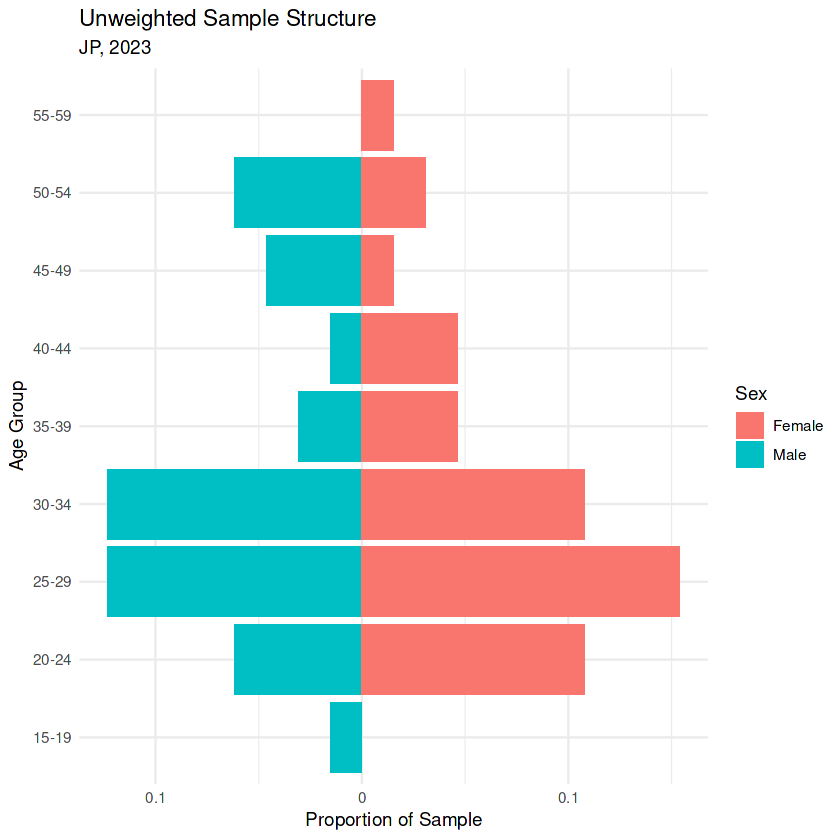

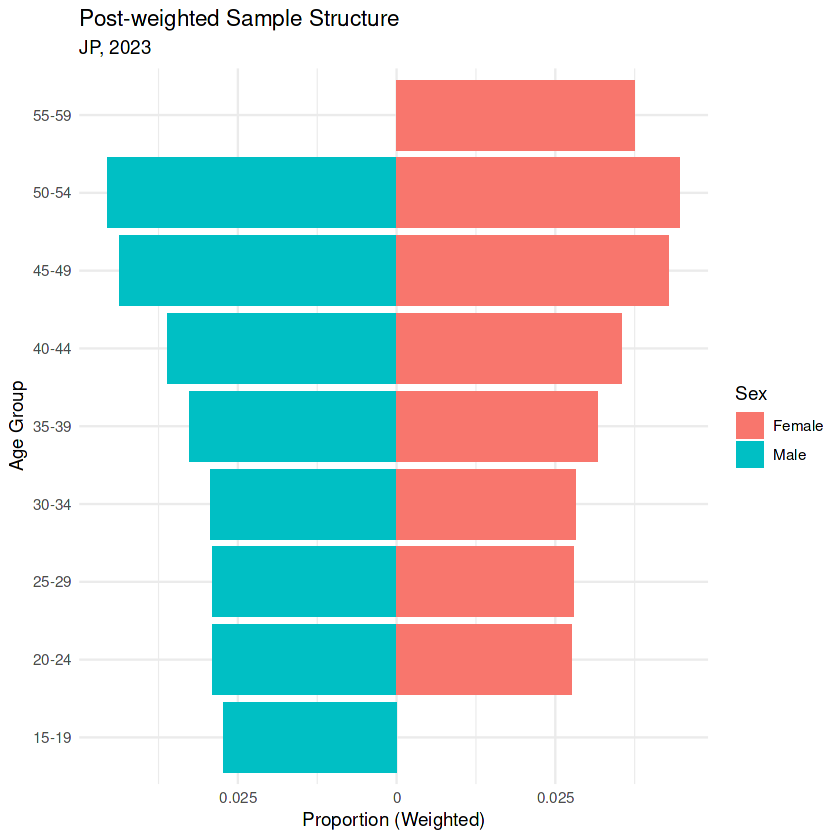

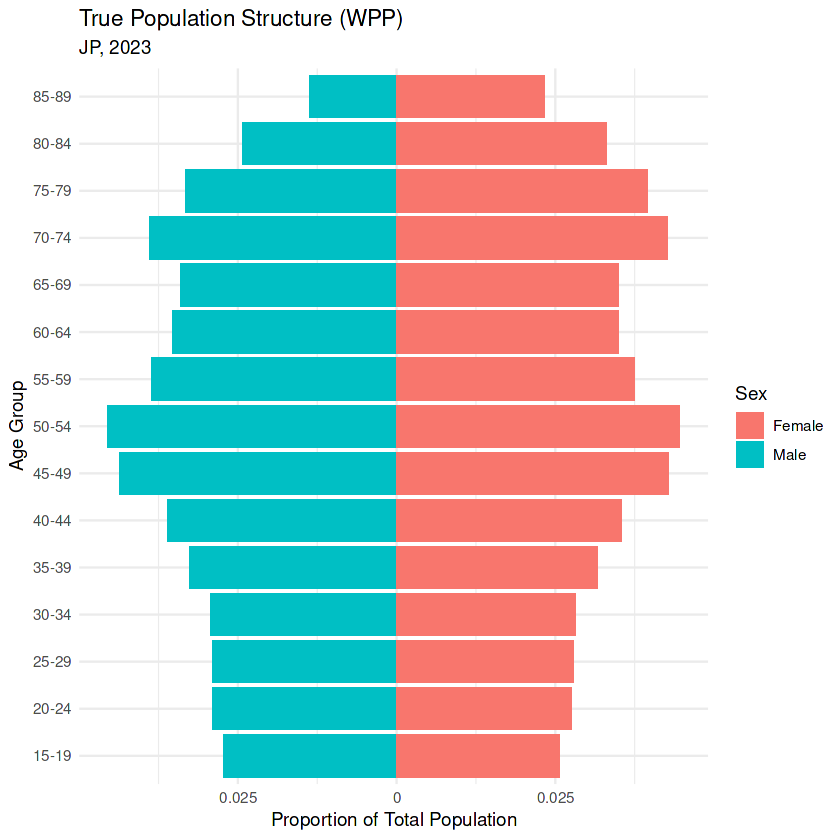

In [40]:
library(ggplot2)
library(dplyr)

# 设置国家和年份
target_country <- "JP"
target_year <- 2023

# ----------------------------------------
# A. 原始样本分布
# ----------------------------------------
plot_sample <- sample_dist %>%
  filter(country_iso == target_country, year == target_year) %>%
  mutate(
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -sample_prop, sample_prop)
  )

ggplot(plot_sample, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "Unweighted Sample Structure",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion of Sample", y = "Age Group") +
  theme_minimal()

# ----------------------------------------
# B. 加权后的样本结构
# ----------------------------------------
plot_weighted <- post_strata_weights %>%
  filter(country_iso == target_country, year == target_year) %>%
  mutate(
    weighted_prop = sample_prop * post_weight,
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -weighted_prop, weighted_prop)
  )

ggplot(plot_weighted, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "Post-weighted Sample Structure",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion (Weighted)", y = "Age Group") +
  theme_minimal()

# ----------------------------------------
# C. WPP 真实人口结构
# ----------------------------------------
plot_true <- true_dist %>%
  filter(country_iso == target_country, Year == target_year) %>%
  mutate(
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -real_prop, real_prop)
  )

ggplot(plot_true, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "True Population Structure (WPP)",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion of Total Population", y = "Age Group") +
  theme_minimal()


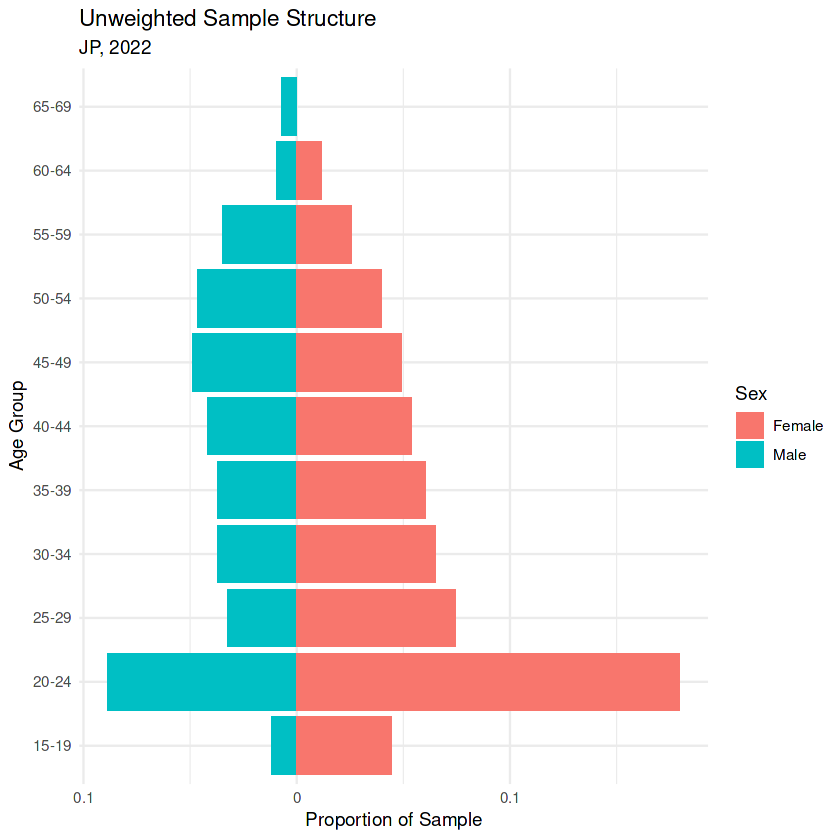

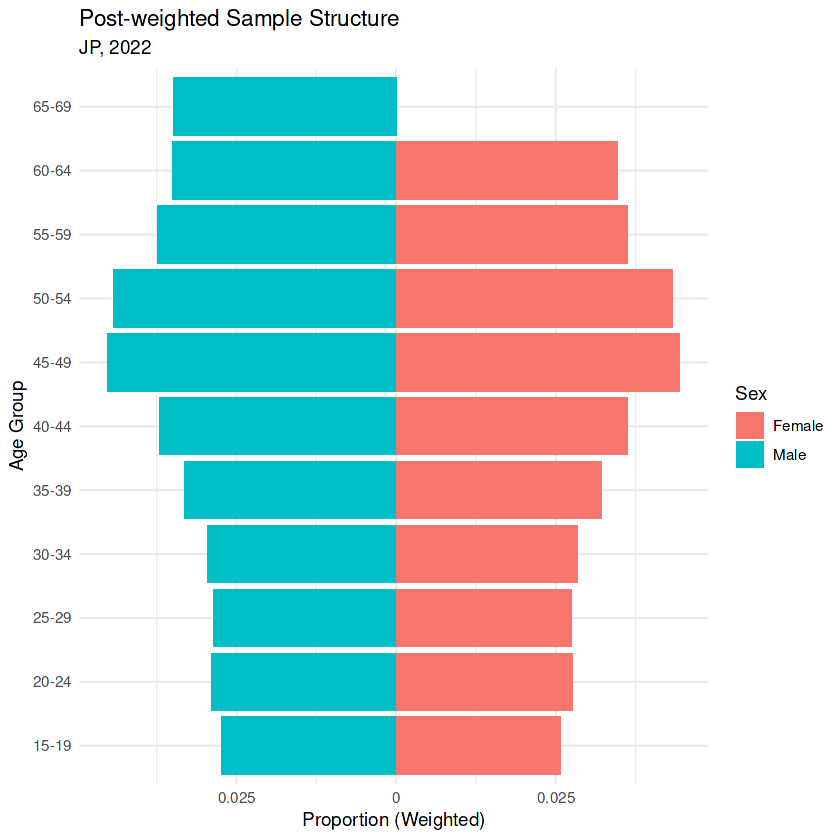

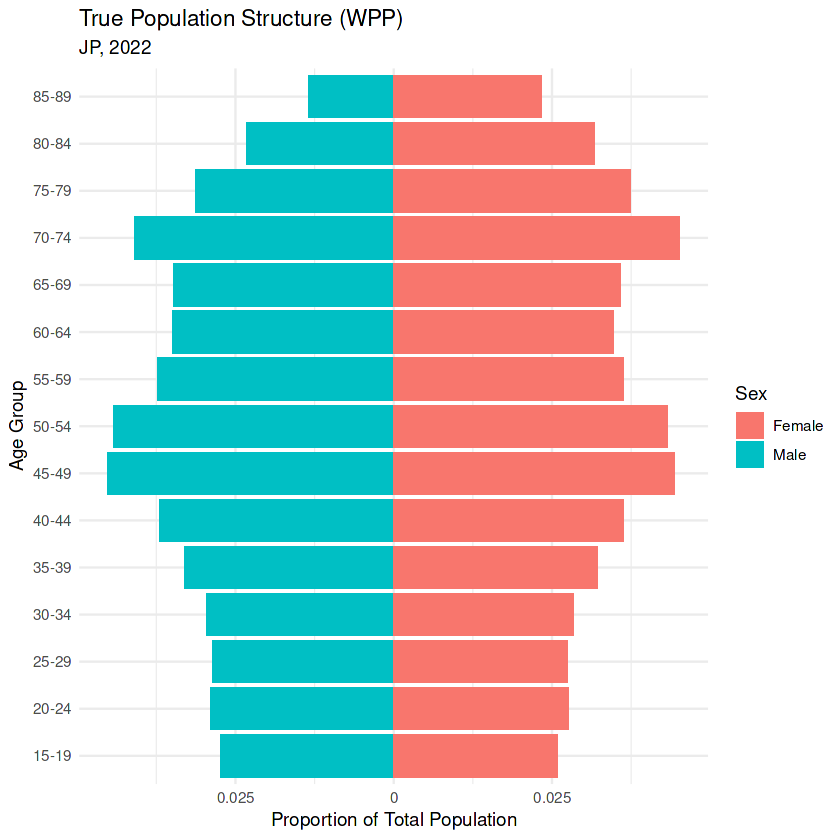

In [41]:
library(ggplot2)
library(dplyr)

# 设置国家和年份
target_country <- "JP"
target_year <- 2022

# ----------------------------------------
# A. 原始样本分布
# ----------------------------------------
plot_sample <- sample_dist %>%
  filter(country_iso == target_country, year == target_year) %>%
  mutate(
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -sample_prop, sample_prop)
  )

ggplot(plot_sample, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "Unweighted Sample Structure",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion of Sample", y = "Age Group") +
  theme_minimal()

# ----------------------------------------
# B. 加权后的样本结构
# ----------------------------------------
plot_weighted <- post_strata_weights %>%
  filter(country_iso == target_country, year == target_year) %>%
  mutate(
    weighted_prop = sample_prop * post_weight,
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -weighted_prop, weighted_prop)
  )

ggplot(plot_weighted, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "Post-weighted Sample Structure",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion (Weighted)", y = "Age Group") +
  theme_minimal()

# ----------------------------------------
# C. WPP 真实人口结构
# ----------------------------------------
plot_true <- true_dist %>%
  filter(country_iso == target_country, Year == target_year) %>%
  mutate(
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -real_prop, real_prop)
  )

ggplot(plot_true, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "True Population Structure (WPP)",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion of Total Population", y = "Age Group") +
  theme_minimal()


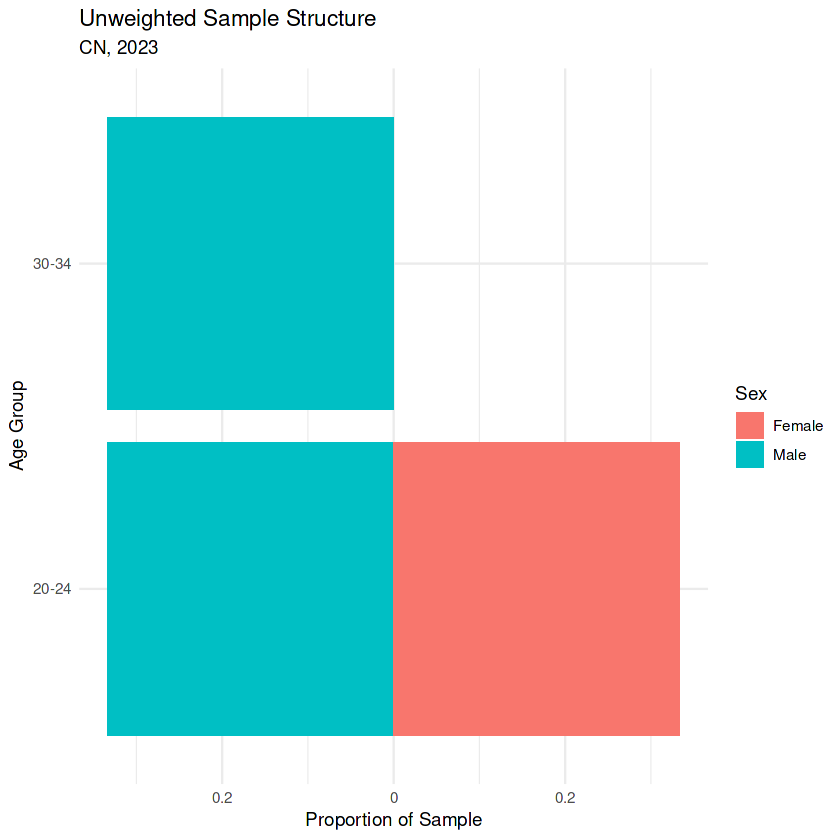

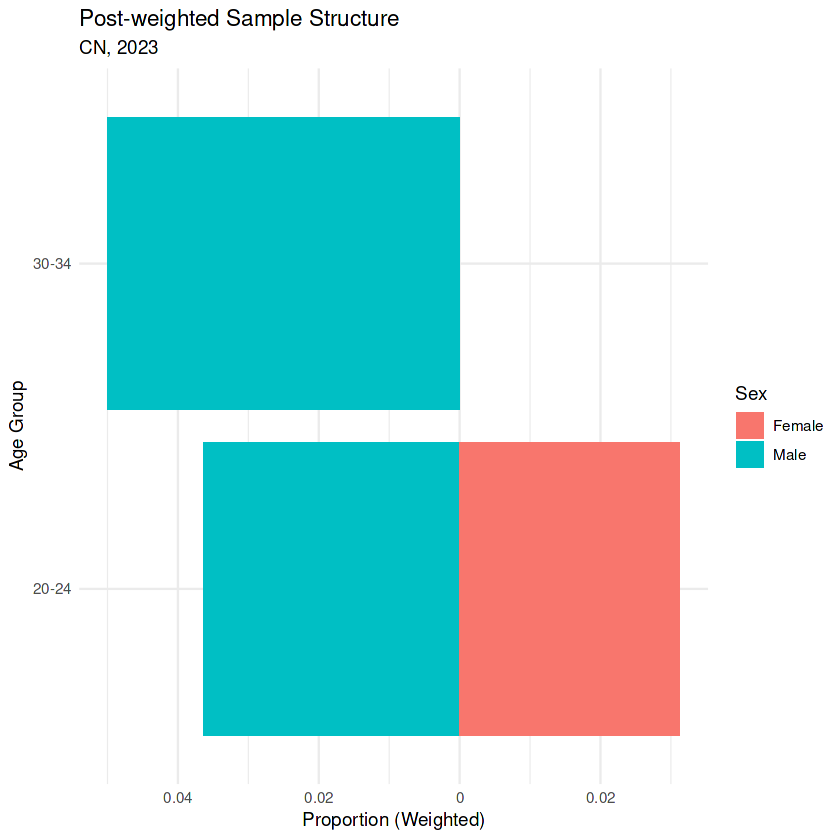

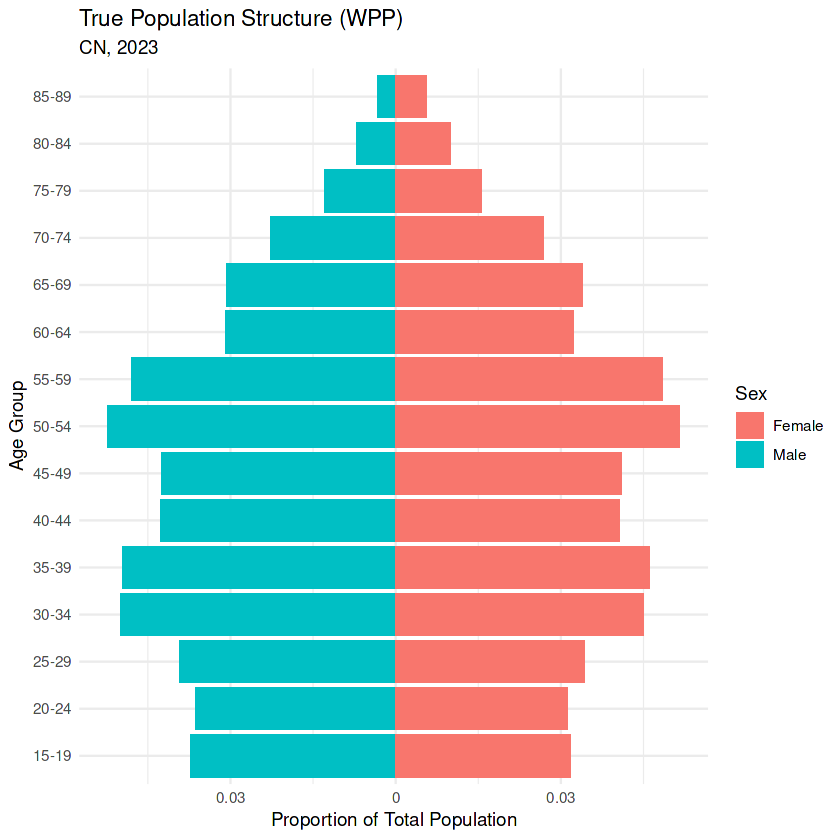

In [42]:
library(ggplot2)
library(dplyr)

# 设置国家和年份
target_country <- "CN"
target_year <- 2023

# ----------------------------------------
# A. 原始样本分布
# ----------------------------------------
plot_sample <- sample_dist %>%
  filter(country_iso == target_country, year == target_year) %>%
  mutate(
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -sample_prop, sample_prop)
  )

ggplot(plot_sample, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "Unweighted Sample Structure",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion of Sample", y = "Age Group") +
  theme_minimal()

# ----------------------------------------
# B. 加权后的样本结构
# ----------------------------------------
plot_weighted <- post_strata_weights %>%
  filter(country_iso == target_country, year == target_year) %>%
  mutate(
    weighted_prop = sample_prop * post_weight,
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -weighted_prop, weighted_prop)
  )

ggplot(plot_weighted, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "Post-weighted Sample Structure",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion (Weighted)", y = "Age Group") +
  theme_minimal()

# ----------------------------------------
# C. WPP 真实人口结构
# ----------------------------------------
plot_true <- true_dist %>%
  filter(country_iso == target_country, Year == target_year) %>%
  mutate(
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -real_prop, real_prop)
  )

ggplot(plot_true, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "True Population Structure (WPP)",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion of Total Population", y = "Age Group") +
  theme_minimal()


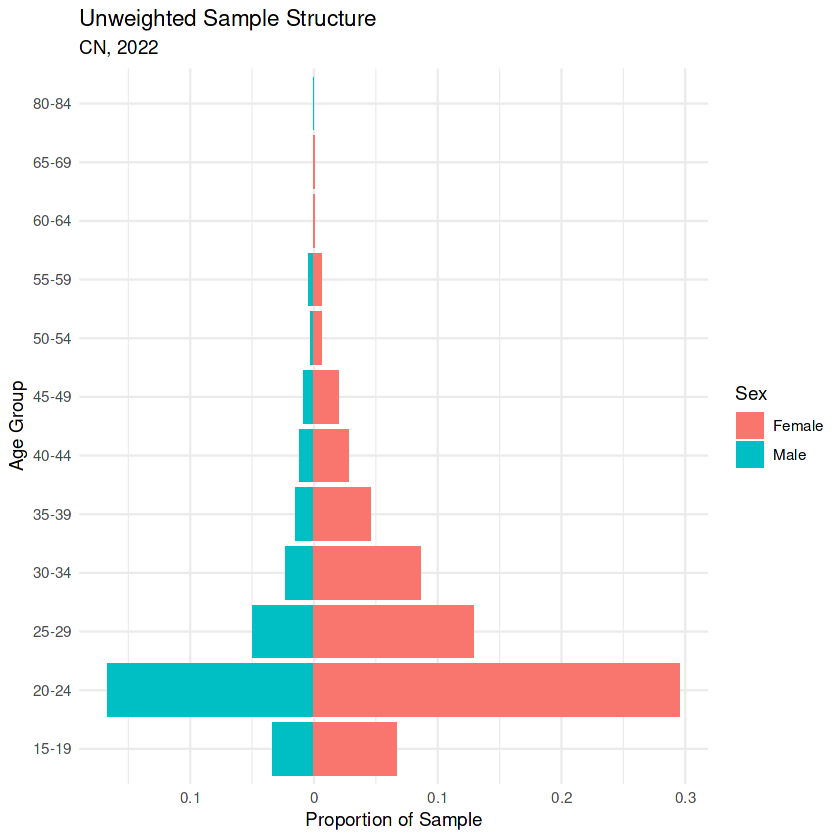

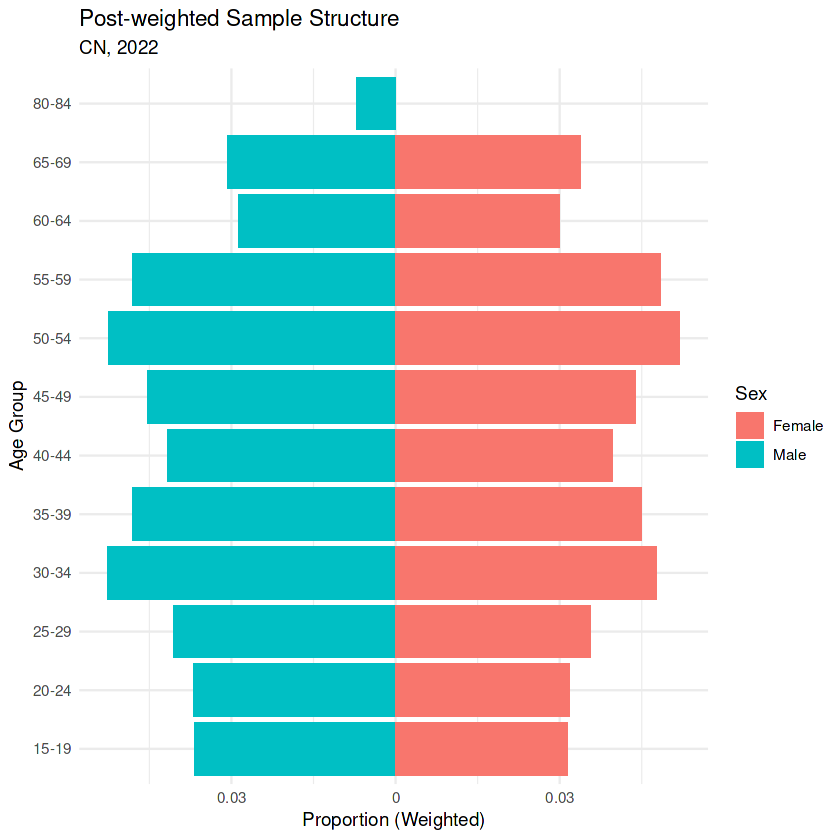

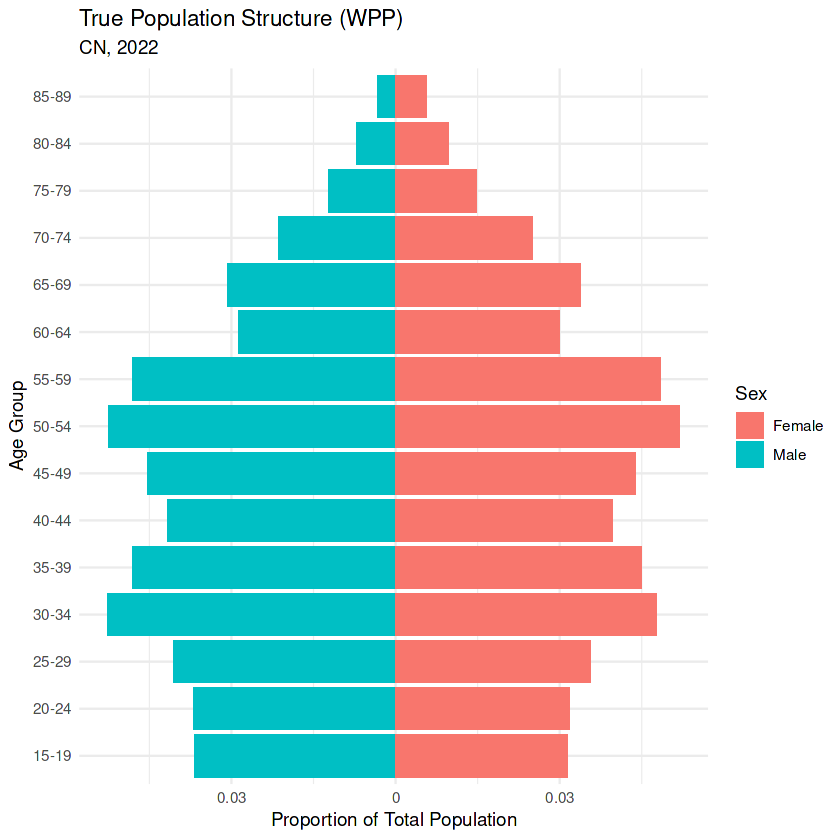

In [43]:
library(ggplot2)
library(dplyr)

# 设置国家和年份
target_country <- "CN"
target_year <- 2022

# ----------------------------------------
# A. 原始样本分布
# ----------------------------------------
plot_sample <- sample_dist %>%
  filter(country_iso == target_country, year == target_year) %>%
  mutate(
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -sample_prop, sample_prop)
  )

ggplot(plot_sample, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "Unweighted Sample Structure",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion of Sample", y = "Age Group") +
  theme_minimal()

# ----------------------------------------
# B. 加权后的样本结构
# ----------------------------------------
plot_weighted <- post_strata_weights %>%
  filter(country_iso == target_country, year == target_year) %>%
  mutate(
    weighted_prop = sample_prop * post_weight,
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -weighted_prop, weighted_prop)
  )

ggplot(plot_weighted, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "Post-weighted Sample Structure",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion (Weighted)", y = "Age Group") +
  theme_minimal()

# ----------------------------------------
# C. WPP 真实人口结构
# ----------------------------------------
plot_true <- true_dist %>%
  filter(country_iso == target_country, Year == target_year) %>%
  mutate(
    Sex = ifelse(Sex == 1, "Male", "Female"),
    value_signed = ifelse(Sex == "Male", -real_prop, real_prop)
  )

ggplot(plot_true, aes(x = value_signed, y = AgeGroup, fill = Sex)) +
  geom_bar(stat = "identity") +
  scale_x_continuous(labels = abs) +
  labs(title = "True Population Structure (WPP)",
       subtitle = paste0(target_country, ", ", target_year),
       x = "Proportion of Total Population", y = "Age Group") +
  theme_minimal()


In [44]:
#第四步，将权重匹配回去：
# 将 post_weight 合并回 survey_data，创建新的 weighted 数据集
survey_data_weighted <- survey_data %>%
  left_join(
    post_strata_weights %>%
      select(country_iso, year, Sex, AgeGroup, post_weight),
    by = c("country_iso", "year", "Sex", "AgeGroup")
  )

# 简单检查合并结果
glimpse(survey_data_weighted)
summary(survey_data_weighted$post_weight)


Rows: 2,448,856
Columns: 52
$ session_id                <dbl> -2999930, -2999920, -2999915, -2999892, -299…
$ age                       <dbl> 19, 30, 35, 24, 22, 26, 28, 36, 43, 18, 19, …
$ birthyear                 <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ year                      <dbl> 2005, 2005, 2005, 2005, 2005, 2005, 2005, 20…
$ sex                       <chr> "f", "f", "m", "f", "f", "n", "m", "m", "m",…
$ birthsex                  <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ genderIdentity_0002       <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ transIdentity             <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ att_5                     <dbl> 3, 3, 3, 4, 3, 3, 4, 4, 3, 3, 4, 4, 3, 4, 4,…
$ att_7                     <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ D_biep.Young_Good_all     <dbl> 0.49379792, 0.11875695, 0.61289950, 1.047096…
$ PCT_error_3467            <dbl> 5.0000000, 6.6666667, 5.8333333, 5.8333333, …
$ pct_400   

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
    0.0     0.4     0.7     1.0     1.2   545.5  352253 

In [45]:
library(dplyr)

# 统计每个国家的样本数量，并按降序排列
country_counts <- survey_data_weighted %>%
  count(country_iso, name = "n") %>%
  arrange(desc(n))

# 查看前几行（前几个国家）
head(country_counts,n=50)

# 可选：写入 CSV 以便在外部查看
write.csv(country_counts, "/kaggle/working/sample_size_by_country.csv", row.names = FALSE)


country_iso,n
<chr>,<int>
UG,1199884
US,647430
NA,119528
CA,54879
UM,47568
AU,25556
IN,23369
UK,18834
DE,14881


In [46]:
survey_data_weighted_filtered <- survey_data_weighted %>%
  filter(country_iso %in% names(table(country_iso)[table(country_iso) > 2000]))


In [47]:
table(survey_data_weighted_filtered$country_iso)
nrow(survey_data_weighted_filtered)
write.csv(survey_data_weighted_filtered,
          "/kaggle/working/survey_data_weighted_filtered.csv",
          row.names = FALSE)



     AF      AR      AT      AU      BE      BR      CA      CC      CH      CN 
   2132    2737    7548   25556    3077    6813   54879    2070    4873   13721 
     CO      DE      DK      FI      FR      GF      GH      HK      ID      IE 
   4440   14881    2651    3249    7703    2060    2728    3393    2014    6903 
     IN      IR      IT      JP      KR      KY      LK      MX      MY      NC 
  23369    8103    6300    3795    5666    6868    4180   12455    2932    5573 
     NE      NL      nu      NZ      PH      PL      PT      QA      RO      RU 
   3357    3286    7217    3658    6645    4197    2279    2053    3416    3721 
     SE      SG      TJ      TK      UG      UK      UM      US      VG      WF 
   2843    5212    2266    4597 1199884   18834   47568  647430    2545    8490 
     ZA 
   4361 

[1] 2236528